# 11b — Delta-sweep Perplexity + Eval-data Visualization (E1 Phase B/C, split out)

`notebooks/11_eval_generation.ipynb` finished generation but its Qwen judge phase never ran
(OPT + 7B judge cannot share VRAM). This notebook does **only** that leftover work:

| step | input | output |
|---|---|---|
| topic spread of the 200 sampled C4 prompts | `gen_main.csv` | `figures/e3b_topic_spread.png` |
| visualization of the PPL evaluation set | both csvs | `figures/e3b_ppl_jobs_*.png` |
| external PPL: 40 seeded sweep texts x delta {0..4} + 50 plain baselines | `gen_sweep.csv`, `gen_main.csv` | `generation/ppl_sweep.csv` |
| quality-vs-strength curve | `ppl_sweep.csv` | `figures/e3b_ppl_vs_delta.png`, `generation/ppl_sweep_meta.json` |

Judge: `Qwen/Qwen1.5-7B` in 4-bit (`load_in_4bit=True`, mandatory on T4); automatic fallback
to `gpt2-large` fp16 if loading/OOM fails — the fallback is logged into the metadata json.
Scoring is continuation-only (prompt tokens masked) via `src/metrics/perplexity.py`.
Chunked checkpointing → safe against Colab disconnects; re-running resumes where it stopped.

**Runtime:** ~15–25 min on T4, ~5–10 min on L4/A100 (250 forward passes).

**CSV location:** expects the files at Drive `minor_project/eval_results/generation/`; also
checks Drive root and repo `data/complete/` as fallbacks.

In [2]:
!git clone https://github.com/pravaspaudel/Dual_watermarking_Scheme.git
!pip install -q transformers scipy pandas matplotlib accelerate bitsandbytes sentencepiece datasets scikit-learn tqdm


Cloning into 'Dual_watermarking_Scheme'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 272 (delta 63), reused 76 (delta 24), pack-reused 151 (from 1)
Receiving objects: 100% (272/272), 43.78 MiB | 26.54 MiB/s, done.
Resolving deltas: 100% (122/122), done.


In [5]:
%cd Dual_watermarking_Scheme

/content/Dual_watermarking_Scheme


In [6]:
# ---- setup ----

import json, os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm as tqdm_auto
from google.colab import drive
drive.mount('/content/drive')

from src.metrics.perplexity import (
    load_judge_model, split_continuation, compute_external_perplexity,
)

CONFIG = {
    "DELTA_SWEEP"   : [0, 1, 2, 3, 4],
    "PPL_PER_DELTA" : 40,      # random sweep texts scored per delta (40x5=200)
    "PPL_BASELINES" : 50,      # plain outputs scored alongside (sentinel delta=-1)
    "SAMPLE_SEED"   : 0,       # identical draw to 11_eval_generation Phase C
    "JUDGE_NAME"    : "Qwen/Qwen1.5-7B",
    "FALLBACK_NAME" : "gpt2-large",
}

DRIVE  = "/content/drive/MyDrive/minor_project"
GENDIR = f"{DRIVE}/eval_results/generation"
FIGDIR = f"{DRIVE}/eval_results/figures"
os.makedirs(GENDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

MAIN_CSV  = f"gen_main.csv"
SWEEP_CSV = f"gen_sweep.csv"
PPL_CSV   = f"{GENDIR}/ppl_sweep.csv"

# csvs may sit in Drive root or repo data/complete instead - take the first hit
for var in ["MAIN_CSV", "SWEEP_CSV"]:
    if not os.path.exists(globals()[var]):
        fname = os.path.basename(globals()[var])
        for alt in [f"{DRIVE}/{fname}", f"data/complete/{fname}"]:
            if os.path.exists(alt):
                globals()[var] = alt
                break
print("main :", MAIN_CSV)
print("sweep:", SWEEP_CSV)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda", "Runtime > Change runtime type > GPU (T4 ok, L4/A100 faster)"

def merge_and_save(buf, path):
    old = pd.read_csv(path) if os.path.exists(path) else None
    merged = pd.concat([old, pd.DataFrame(buf)]) if old is not None else pd.DataFrame(buf)
    merged.to_csv(path, index=False)

print("device:", DEVICE, "| gpu:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
main : gen_main.csv
sweep: gen_sweep.csv
device: cuda | gpu: Tesla T4


In [7]:
MAIN_CSV  = f"../gen_main.csv"
SWEEP_CSV = f"../gen_sweep.csv"



In [8]:
# ---- load corpora + QA ----
main_df  = pd.read_csv(MAIN_CSV)
sweep_df = pd.read_csv(SWEEP_CSV)

assert len(main_df) == 800,  f"gen_main has {len(main_df)} rows, expected 800"
assert len(sweep_df) == 250, f"gen_sweep has {len(sweep_df)} rows, expected 250"
assert not main_df["text"].isna().any() and not sweep_df["text"].isna().any()
assert set(main_df["variant"]) == {"plain", "l1_only", "l2_only", "dual"}
print("gen_main :", len(main_df), "rows | variants:", main_df["variant"].value_counts().to_dict())
print("gen_sweep:", len(sweep_df), "rows | deltas:",
      sweep_df["delta_public_sweep"].value_counts().sort_index().to_dict())

gen_main : 800 rows | variants: {'plain': 200, 'l1_only': 200, 'l2_only': 200, 'dual': 200}
gen_sweep: 250 rows | deltas: {0.0: 50, 1.0: 50, 2.0: 50, 3.0: 50, 4.0: 50}


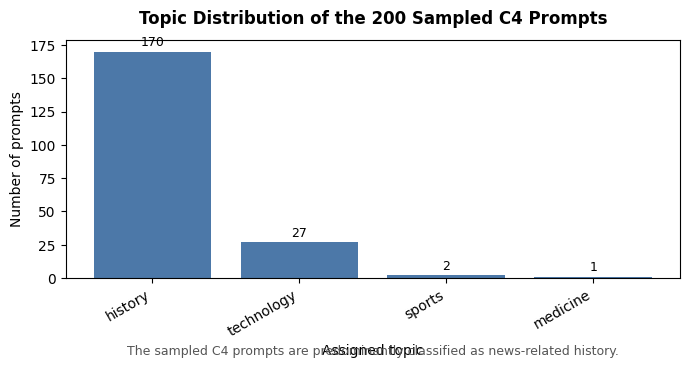

topic
history       170
technology     27
sports          2
medicine        1


In [9]:
# ---- Figure 1: Topic distribution of sampled prompts ----
prompts = main_df.drop_duplicates("id")
topic_counts = prompts["topic"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(topic_counts.index, topic_counts.values, color="#4c78a8")

ax.bar_label(bars, padding=2, fontsize=9)
ax.set_xlabel("Assigned topic")
ax.set_ylabel("Number of prompts")
ax.set_title(
    f"Topic Distribution of the {len(prompts)} Sampled C4 Prompts",
    pad=12,
    weight="bold",
)
ax.text(
    0.5, -0.32,
    "The sampled C4 prompts are predominantly classified as news-related history.",
    transform=ax.transAxes,
    ha="center",
    fontsize=9,
    color="#555555",
)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3b_topic_spread.png", dpi=300, bbox_inches="tight")
plt.show()

print(topic_counts.to_string())

In [12]:
# ---- build the PPL job list (same seeded draw as 11 Phase C) ----
rng = np.random.default_rng(CONFIG["SAMPLE_SEED"])
picked = []
for d in CONFIG["DELTA_SWEEP"]:
    pool = sweep_df[sweep_df["delta_public_sweep"] == d]
    picked.append(pool.sample(n=min(CONFIG["PPL_PER_DELTA"], len(pool)),
                              random_state=int(rng.integers(1 << 31))))
ppl_targets = pd.concat(picked)

base_ids = sorted(main_df["id"].unique())[:CONFIG["PPL_BASELINES"]]
baselines = main_df[(main_df["variant"] == "plain") & (main_df["id"].isin(base_ids))]
baselines = baselines.assign(delta_public_sweep=-1.0)          # sentinel = baseline

jobs = pd.concat([
    ppl_targets,
    baselines[["id", "prompt_text", "topic", "delta_public_sweep", "text"]],
])[["id", "prompt_text", "topic", "delta_public_sweep", "text"]].reset_index(drop=True)
jobs["cont_words"] = jobs.apply(
    lambda r: len(split_continuation(r["prompt_text"], r["text"]).split()), axis=1)
jobs["group"] = jobs["delta_public_sweep"].map(
    lambda d: "plain_baseline" if d < 0 else f"dual δ={int(d)}")

n_empty = int((jobs["cont_words"] == 0).sum())
print(f"PPL jobs: {len(jobs)} ({len(ppl_targets)} sweep + {len(baselines)} baselines)"
      f" | empty continuations: {n_empty}")
print(jobs.groupby("group").agg(n=("id", "size"), mean_words=("cont_words", "mean")).round(1))

PPL jobs: 250 (200 sweep + 50 baselines) | empty continuations: 3
                 n  mean_words
group                         
dual δ=0        40       138.8
dual δ=1        40       137.9
dual δ=2        40       149.6
dual δ=3        40       143.0
dual δ=4        40       133.6
plain_baseline  50       125.6


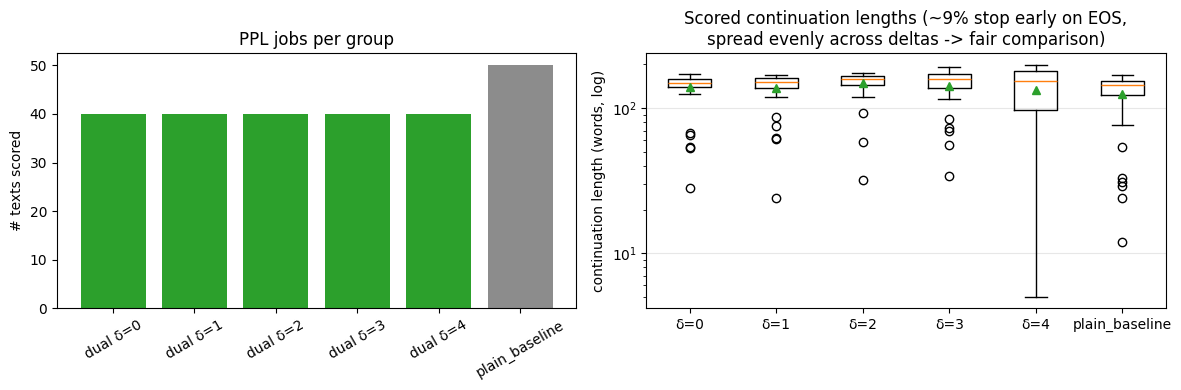

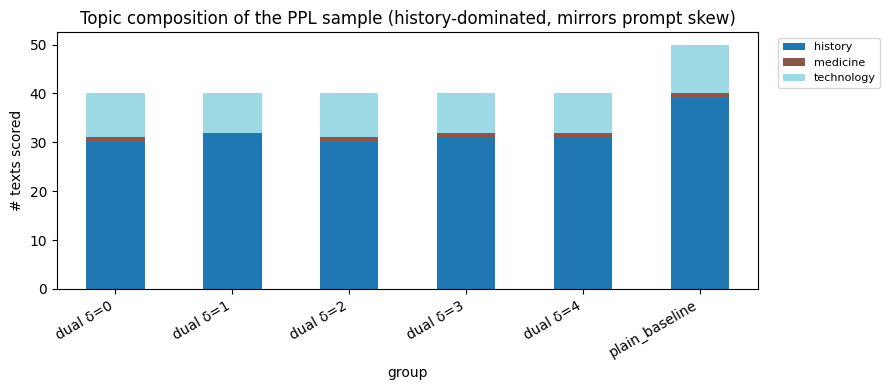

                    pool  sampled
delta_public_sweep               
0.0                   50       40
1.0                   50       40
2.0                   50       40
3.0                   50       40
4.0                   50       40


In [13]:
# ---- graphs 2-4: what exactly gets scored, spread along delta ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) job counts per group
cnt = jobs.groupby("group").size().reindex(
    [f"dual δ={d}" for d in CONFIG["DELTA_SWEEP"]] + ["plain_baseline"])
axes[0].bar(cnt.index, cnt.values, color=["#2ca02c"]*5 + ["#8c8c8c"])
axes[0].set_ylabel("# texts scored")
axes[0].set_title("PPL jobs per group")
axes[0].tick_params(axis="x", rotation=30)

# (b) continuation length distribution per group (log y - a few EOS-stopped shorts)
groups = list(cnt.index)
data = [jobs.loc[jobs["group"] == g, "cont_words"].values for g in groups]
axes[1].boxplot(data, showmeans=True)
axes[1].set_xticks(range(1, len(groups) + 1))
axes[1].set_xticklabels([g.replace("dual ", "") for g in groups])
axes[1].set_yscale("log")
axes[1].set_ylabel("continuation length (words, log)")
axes[1].set_title("Scored continuation lengths (~9% stop early on EOS,\nspread evenly across deltas -> fair comparison)")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3b_ppl_jobs_counts_lengths.png", dpi=300)
plt.show()

# (c) topic composition of the scored sample per delta
ct = pd.crosstab(jobs["group"], jobs["topic"])
ct = ct.reindex([f"dual δ={d}" for d in CONFIG["DELTA_SWEEP"]] + ["plain_baseline"])
ax = ct.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="tab20")
ax.set_ylabel("# texts scored")
ax.set_title("Topic composition of the PPL sample (history-dominated, mirrors prompt skew)")
plt.xticks(rotation=30, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3b_ppl_jobs_topics.png", dpi=300)
plt.show()

# (d) sweep-pool coverage sanity: sampled ids vs available pool per delta
cov = pd.DataFrame({
    "pool":     sweep_df.groupby("delta_public_sweep").size(),
    "sampled":  ppl_targets.groupby("delta_public_sweep").size(),
})
print(cov.to_string())

In [1]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


In [11]:
# ---- load the judge: Qwen1.5-7B 4-bit (fallback gpt2-large fp16) ----
judge_name, used_fallback, used_4bit = CONFIG["JUDGE_NAME"], False, True
try:
    judge_model, judge_tokenizer = load_judge_model(
        CONFIG["JUDGE_NAME"], device=DEVICE,
        torch_dtype=torch.float16, load_in_4bit=True,
    )
except Exception as e:
    print(f"[warn] {CONFIG['JUDGE_NAME']} failed ({type(e).__name__}: {e})")
    print(f"[warn] falling back to {CONFIG['FALLBACK_NAME']} fp16 - LOGGED to metadata")
    judge_name, used_fallback, used_4bit = CONFIG["FALLBACK_NAME"], True, False
    judge_model, judge_tokenizer = load_judge_model(
        CONFIG["FALLBACK_NAME"], device=DEVICE, torch_dtype=torch.float16)

dtype = next(judge_model.parameters()).dtype
print(f"judge={judge_name} | dtype={dtype} | 4bit={used_4bit} | "
      f"device={[str(d) for _, d in judge_model.named_parameters()][:1]}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

[warn] Qwen/Qwen1.5-7B failed (TypeError: Qwen2ForCausalLM.__init__() got an unexpected keyword argument 'load_in_4bit')
[warn] falling back to gpt2-large fp16 - LOGGED to metadata


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.25GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

judge=gpt2-large | dtype=torch.float16 | 4bit=False | device=["Parameter containing:\ntensor([[-0.0149, -0.0209,  0.0021,  ...,  0.0336, -0.0005, -0.0090],\n        [ 0.0055, -0.0438,  0.0013,  ...,  0.0671,  0.0330, -0.0399],\n        [ 0.0585,  0.0603,  0.0302,  ..., -0.1041, -0.0566, -0.0330],\n        ...,\n        [-0.0108, -0.0908,  0.0623,  ..., -0.0337,  0.0776,  0.0293],\n        [ 0.0195, -0.0318,  0.0182,  ...,  0.0191, -0.0454, -0.0139],\n        [-0.0419,  0.0848, -0.0512,  ..., -0.0083, -0.0447, -0.0274]],\n       device='cuda:0', dtype=torch.float16, requires_grad=True)"]


In [14]:
# ---- score: external PPL, continuation-only, resumable chunked saves ----
done_ppl = set()
if os.path.exists(PPL_CSV):
    done_ppl = set(map(tuple,
        pd.read_csv(PPL_CSV)[["id", "delta_public_sweep"]].values.astype(float)))
    print(f"resume: {len(done_ppl)} jobs already scored")

buf, t0 = [], time.time()
for rec in tqdm_auto(jobs.to_dict("records"), desc="external PPL"):
    key_t = (float(rec["id"]), float(rec["delta_public_sweep"]))
    if key_t in done_ppl:
        continue
    cont = split_continuation(rec["prompt_text"], rec["text"])
    buf.append({
        "id": rec["id"],
        "delta_public_sweep": rec["delta_public_sweep"],
        "topic": rec["topic"],
        "variant": "dual_sweep" if rec["delta_public_sweep"] >= 0 else "plain_baseline",
        "external_ppl": compute_external_perplexity(
            rec["prompt_text"], cont, judge_model, judge_tokenizer, DEVICE),
    })
    if len(buf) >= 5:
        merge_and_save(buf, PPL_CSV); buf = []
if buf:
    merge_and_save(buf, PPL_CSV)

ppl_df = pd.read_csv(PPL_CSV)
t_ppl = time.time() - t0
meta = {"judge": judge_name, "dtype": str(dtype), "load_in_4bit": used_4bit,
        "fallback_used": used_fallback, "rows": len(ppl_df),
        "scoring_minutes": round(t_ppl / 60, 2), "gpu": torch.cuda.get_device_name(0)}
with open(f"{GENDIR}/ppl_sweep_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))
print(f"\nPPL scoring: {len(ppl_df)} rows in {t_ppl/60:.1f} min"
      f" | NaN ppl rows: {int(ppl_df['external_ppl'].isna().sum())}")

external PPL:   0%|          | 0/250 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


{
  "judge": "gpt2-large",
  "dtype": "torch.float16",
  "load_in_4bit": false,
  "fallback_used": true,
  "rows": 250,
  "scoring_minutes": 0.19,
  "gpu": "Tesla T4"
}

PPL scoring: 250 rows in 0.2 min | NaN ppl rows: 3


                      mean     std  count
delta_public_sweep                       
0.0                  9.163   3.045     40
1.0                  9.093   2.570     39
2.0                 10.788   6.206     40
3.0                 13.092   5.705     39
4.0                 21.007  37.242     40

plain baseline: 7.830 +/- 2.711 (n=50)
  delta 0: dual PPL 9.16 = baseline +17.0%
  delta 1: dual PPL 9.09 = baseline +16.1%
  delta 2: dual PPL 10.79 = baseline +37.8%
  delta 3: dual PPL 13.09 = baseline +67.2%
  delta 4: dual PPL 21.01 = baseline +168.3%


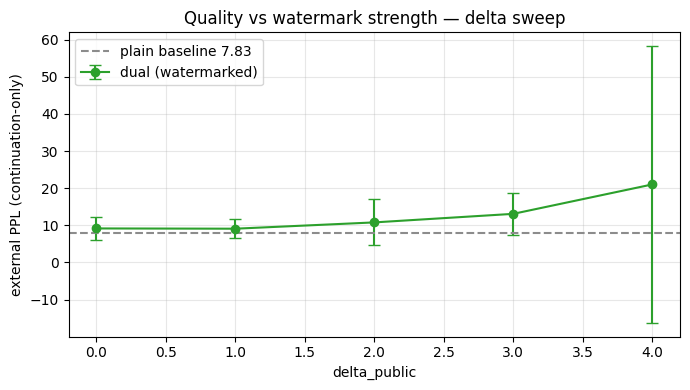


acceptance checks:
  plain band sane (single digits-low tens): mean=7.83
  delta 0 ≈ plain (should be within noise): see table above
  degradation grows monotonically-ish with delta: see plot

saved: /content/drive/MyDrive/minor_project/eval_results/generation/ppl_sweep.csv
saved: /content/drive/MyDrive/minor_project/eval_results/figures/{e3b_topic_spread,e3b_ppl_jobs_counts_lengths,e3b_ppl_jobs_topics,e3b_ppl_vs_delta}.png


In [15]:
# ---- results: table + THE trade-off curve ----
curve = (ppl_df[ppl_df["delta_public_sweep"] >= 0]
         .groupby("delta_public_sweep")["external_ppl"]
         .agg(["mean", "std", "count"]).round(3))
base_mask = ppl_df["delta_public_sweep"] < 0
baseline_mean = ppl_df.loc[base_mask, "external_ppl"].mean()
baseline_std  = ppl_df.loc[base_mask, "external_ppl"].std()

print(curve.to_string())
print(f"\nplain baseline: {baseline_mean:.3f} +/- {baseline_std:.3f} (n={int(base_mask.sum())})")
for d, row in curve.iterrows():
    gap = (row["mean"] - baseline_mean) / baseline_mean * 100
    print(f"  delta {int(d)}: dual PPL {row['mean']:.2f} = baseline {gap:+.1f}%")

plt.figure(figsize=(7, 4))
plt.errorbar(curve.index, curve["mean"], yerr=curve["std"],
             marker="o", capsize=4, color="#2ca02c", label="dual (watermarked)")
plt.axhline(baseline_mean, ls="--", color="#8c8c8c",
            label=f"plain baseline {baseline_mean:.2f}")
plt.xlabel("delta_public")
plt.ylabel("external PPL (continuation-only)")
plt.title("Quality vs watermark strength — delta sweep")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/e3b_ppl_vs_delta.png", dpi=300)
plt.show()

print("\nacceptance checks:")
print(f"  plain band sane (single digits-low tens): mean={baseline_mean:.2f}")
print(f"  delta 0 ≈ plain (should be within noise): see table above")
print(f"  degradation grows monotonically-ish with delta: see plot")
print("\nsaved:", PPL_CSV)
print("saved:", f"{FIGDIR}" + "/{e3b_topic_spread,e3b_ppl_jobs_counts_lengths,e3b_ppl_jobs_topics,e3b_ppl_vs_delta}.png")